# Project 1:  Clustering Algorithms

## Assignment Overview

### Objective:
To provide students with hands-on experience in implementing clustering techniques on real-world datasets.

### About the data:
The Economist Democracy Index is an annual index compiled by the UK-based magazine, The Economist,   
through its Economist Intelligence Unit (EIU). This index rates the state of democracy across countries worldwide.    
  
It is based on five categories:

- **Electoral Process and Pluralism:**   
This measures the fairness of elections, the freedom to form political parties, and the participation of various groups in the political process.  

- **Functioning of Government:** This evaluates how effectively governments operate, the quality of governance, the level of corruption, and whether political decisions are made in a transparent manner. 

- **Political Participation:** This assesses the level of public involvement in politics, including voter turnout, membership in political parties, and engagement with political issues. 
 
- **Political Culture:** This looks at the societal norms and attitudes towards politics, including the extent to which different viewpoints are tolerated and the relationship between government and religion. 

- **Civil Liberties:** This gauges the extent of individual freedoms, including freedom of speech, freedom of the press, and the right to protest. 


**Countries are classified into four types of regimes based on their scores:**
 
- Full democracies 
- Flawed democracies 
- Hybrid regimes 
- Authoritarian regimes 

The Democracy Index is widely referenced in political and academic circles as a comprehensive measure of the state of democracy globally.   
It provides a snapshot of the health of democracy in each country and also allows for comparisons across countries and over time. 

[Additional information on Democracy Index ](https://en.wikipedia.org/wiki/The_Economist_Democracy_Index)

## Step 1: Access the dataset for use in your Notebook.   

You can find a csv version of this dataset already installed in your lab as `democracy_index.csv`, or download it for local use through 
[this link](https://github.com/JustGlowing/minisom/blob/master/examples/democracy_index.csv). 

## **Step 2:**  Clustering Implementation (Tasks) 

Please follow and complete each step below to complete the assignment.

### **Task 1:** Load the democracy index data set 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


dataset = pd.read_csv("democracy_index.csv")
#load the csv dataset and present the first 10 rows
dataset.head(10)

,Unnamed: 0,rank,country,democracy_index,electoral_processand_pluralism,functioning_of_government,political_participation,political_culture,civil_liberties,category
0,0,1,Norway,9.87,10.00,9.64,10.00,10.00,9.71,Full democracy
1,1,2,Iceland,9.58,10.00,9.29,8.89,10.00,9.71,Full democracy
2,2,3,Sweden,9.39,9.58,9.64,8.33,10.00,9.41,Full democracy
3,3,4,New Zealand,9.26,10.00,9.29,8.89,8.13,10.00,Full democracy
4,4,5,Denmark,9.22,10.00,9.29,8.33,9.38,9.12,Full democracy
5,5,=6,Ireland,9.15,9.58,7.86,8.33,10.00,10.00,Full democracy
6,6,=6,Canada,9.15,9.58,9.64,7.78,8.75,10.00,Full democracy
7,7,8,Finland,9.14,10.00,8.93,8.33,8.75,9.71,Full democracy
8,8,9,Australia,9.09,10.00,8.93,7.78,8.75,10.00,Full democracy
9,9,10,Switzerland,9.03,9.58,9.29,7.78,9.38,9.12,Full democracy


### **Task 2:**  Use the five categories to cluster countries into different regimes 

In [ ]:
data = dataset[['electoral_processand_pluralism', 'functioning_of_government', 'political_participation', 'political_culture', 'civil_liberties']]
#these five categories will be used to cluster the countries. All other columns in the dataset are not needed
#this creates a new dataframe with only the data from these categories

### **Task 3:**  Preprocess the data (if necessary), such as normalizing or scaling the features 
**a:** Find out why we need to maintain a uniform scale across the variables for K-means and Hierarchical clustering  
**b:** Do we need to use scaling techniques for this dataset? 


In [ ]:
#scaler = preprocessing.StandardScaler()
#scaled_data = scaler.fit_transform(data)
#scaled_df = pd.DataFrame(scaled_data, columns=data.columns)
#scaled_df

scaler = preprocessing.MinMaxScaler()
normalized_data = scaler.fit_transform(data)
normalized_df = pd.DataFrame(normalized_data, columns=data.columns)
normalized_df

,electoral_processand_pluralism,functioning_of_government,political_participation,political_culture,civil_liberties
0,1.000,1.000000,1.000000,1.000000,0.971
1,1.000,0.963693,0.875141,1.000000,0.971
2,0.958,1.000000,0.812148,1.000000,0.941
3,1.000,0.963693,0.875141,0.786286,1.000
4,1.000,0.963693,0.812148,0.929143,0.912
...,...,...,...,...,...
162,0.000,0.000000,0.062992,0.285714,0.265
163,0.225,0.000000,0.000000,0.072000,0.235
164,0.050,0.073651,0.124859,0.214857,0.088
165,0.000,0.000000,0.187852,0.357714,0.000


The MinMaxScaler was used over the StandardScaler due to the values being positive between 0 and 1, compared to the standard [-1, 1]. 

A uniform scale is needed for K-means and hierchical clustering to eliminate bias from lower or higher values. For this dataset specifically, scaling techniques are not needed, as every value has a uniform range. However, the MinMax scaler is used for this project. This scaler has essentially divided every value by 10, changing the range from [0,10] to [0,1].

### **Task 4:**  Implement K-means clustering to categorize the data into clusters 
**a:** Use elbow method to determine number of clusters   
**b:** Verify if the solution offered by the elbow method and the actual soultion (number of regimes) match   
**c:** Do we need to use elbow method to detrmine number of clusters for this dataset?   


[57.34455217357806, 21.03271536344508, 14.27577474249863, 11.5010078792899, 9.974085361901757, 9.185847240620578, 8.502505116738654, 8.130660722929516, 7.320904800166503, 6.929035783762143]


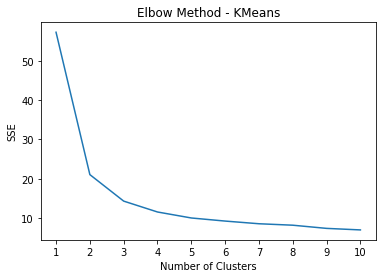

In [ ]:
sse = []
#list to hold SSE value for each cluster value k
k_values = range(1,11)
# defines a range for the number of clusters tested
for k in k_values:
    kmeans = KMeans(init="random", n_clusters=k, n_init=10, random_state=1)
    kmeans.fit(normalized_df)
    sse.append(kmeans.inertia_)
    #calculates the SSE value for each k
    
print(sse)
#print the values in order to compare to the graph

#plot the Kmeans values on the graph
plt.plot(k_values, sse)
plt.xticks(k_values)
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method - KMeans")
plt.show()

Using the elbow method, the graph depicts the elbow to be at the 3rd cluster. However, the actual solution is 4 clusters to match the number of regimes. When evaluating the difference of SSE values when printed, we notice that the change in SSE values between cluster 3 and cluster 4 are still significant. It is at cluster 5 and beyond that the change in SSE values becomes insignificant enough. 

Below depicts the K-means clustering graphed for both 3 clusters, as depicted by the elbow, and 4 clusters, as depicted by the number of regimes, or the actual solution.

In [ ]:
kmeans = KMeans(init="random", n_clusters=3, n_init=10, random_state=1)
clusters = kmeans.fit_predict(normalized_df)
dataset['cluster'] = kmeans.labels_
dataset
#annotates the number of the cluster that each row belongs to, using 3 clusters

,Unnamed: 0,rank,country,democracy_index,electoral_processand_pluralism,functioning_of_government,political_participation,political_culture,civil_liberties,category,cluster
0,0,1,Norway,9.87,10.00,9.64,10.00,10.00,9.71,Full democracy,0
1,1,2,Iceland,9.58,10.00,9.29,8.89,10.00,9.71,Full democracy,0
2,2,3,Sweden,9.39,9.58,9.64,8.33,10.00,9.41,Full democracy,0
3,3,4,New Zealand,9.26,10.00,9.29,8.89,8.13,10.00,Full democracy,0
4,4,5,Denmark,9.22,10.00,9.29,8.33,9.38,9.12,Full democracy,0
...,...,...,...,...,...,...,...,...,...,...,...
162,162,163,Chad,1.61,0.00,0.00,1.67,3.75,2.65,Authoritarian,1
163,163,164,Central African Republic,1.52,2.25,0.00,1.11,1.88,2.35,Authoritarian,1
164,164,165,Democratic Republic of the Congo,1.49,0.50,0.71,2.22,3.13,0.88,Authoritarian,1
165,165,166,Syria,1.43,0.00,0.00,2.78,4.38,0.00,Authoritarian,1


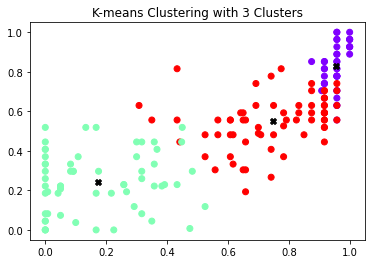

In [ ]:
plt.scatter(normalized_df['electoral_processand_pluralism'], normalized_df['functioning_of_government'], c=clusters, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X')
plt.title("K-means Clustering with 3 Clusters")
plt.show()
#the graph depicts the dataset with 3 clusters and their centroids.

In [ ]:
kmeans = KMeans(init="random", n_clusters=4, n_init=10, random_state=1)
clusters = kmeans.fit_predict(normalized_df)
dataset['cluster'] = kmeans.labels_
dataset
#annotates the number of the cluster that each row belongs to, using 3 clusters

,Unnamed: 0,rank,country,democracy_index,electoral_processand_pluralism,functioning_of_government,political_participation,political_culture,civil_liberties,category,cluster
0,0,1,Norway,9.87,10.00,9.64,10.00,10.00,9.71,Full democracy,2
1,1,2,Iceland,9.58,10.00,9.29,8.89,10.00,9.71,Full democracy,2
2,2,3,Sweden,9.39,9.58,9.64,8.33,10.00,9.41,Full democracy,2
3,3,4,New Zealand,9.26,10.00,9.29,8.89,8.13,10.00,Full democracy,2
4,4,5,Denmark,9.22,10.00,9.29,8.33,9.38,9.12,Full democracy,2
...,...,...,...,...,...,...,...,...,...,...,...
162,162,163,Chad,1.61,0.00,0.00,1.67,3.75,2.65,Authoritarian,3
163,163,164,Central African Republic,1.52,2.25,0.00,1.11,1.88,2.35,Authoritarian,3
164,164,165,Democratic Republic of the Congo,1.49,0.50,0.71,2.22,3.13,0.88,Authoritarian,3
165,165,166,Syria,1.43,0.00,0.00,2.78,4.38,0.00,Authoritarian,3


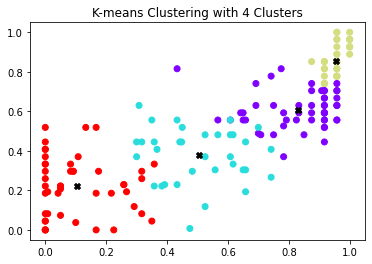

In [ ]:
plt.scatter(normalized_df['electoral_processand_pluralism'], normalized_df['functioning_of_government'], c=clusters, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X')
plt.title("K-means Clustering with 4 Clusters")
plt.show()
#this graph depicts the dataset using 4 K-means clusters.

The graph depicting 4 clusters shows a better representation of the points in relation to their centroids. Therefore, k=4 clusters is better than the graph depicted by the elbow method. For this project specifically, the elbow method to figure out the number of clusters needed was redundant, as it was known that there were four regimes.

### **Task 5:**  Implement Hierarchical clustering using an appropriate linkage method 
**a:** Try different linkage criteria 

In [ ]:
#Agglomerative Clustering for hierarchical clustering is used
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_clusters = agg_clustering.fit_predict(normalized_df)
#agg_clusters

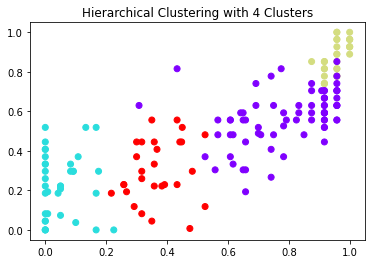

In [ ]:
# Plotting the clusters
plt.scatter(normalized_df['electoral_processand_pluralism'], normalized_df['functioning_of_government'], c=agg_clusters, cmap='rainbow')
plt.title("Hierarchical Clustering with 4 Clusters")
plt.show()

When comparing the Agglomerative clusters with the K-means clusters, there are noticable changes to the amount of countries assigned to each cluster, with the majority of countries shifting around clusters 1 through 3.

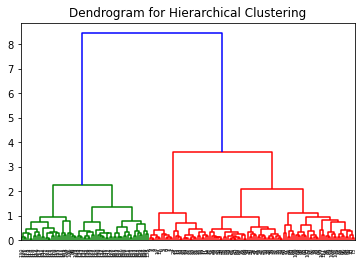

In [ ]:
# Generating a dendrogram
linked = linkage(normalized_df, 'ward')


dendrogram(linked, orientation='top')
plt.title("Dendrogram for Hierarchical Clustering")
plt.show()

The dendogram is another form of heiarchical clustering, in which the graph depicts the distances between each point as the heights of the clusters. The lower the height, the closer the two points are, and vice versa.

### **Task 6:** Plot the democracy index values

For aforementioned methods generate the clustering solution. The clustering solution simply groups the countries into different groups   
based on similarity. Once the solution is obtained, plot density plots of democracy index values considering all the countries within a group. 


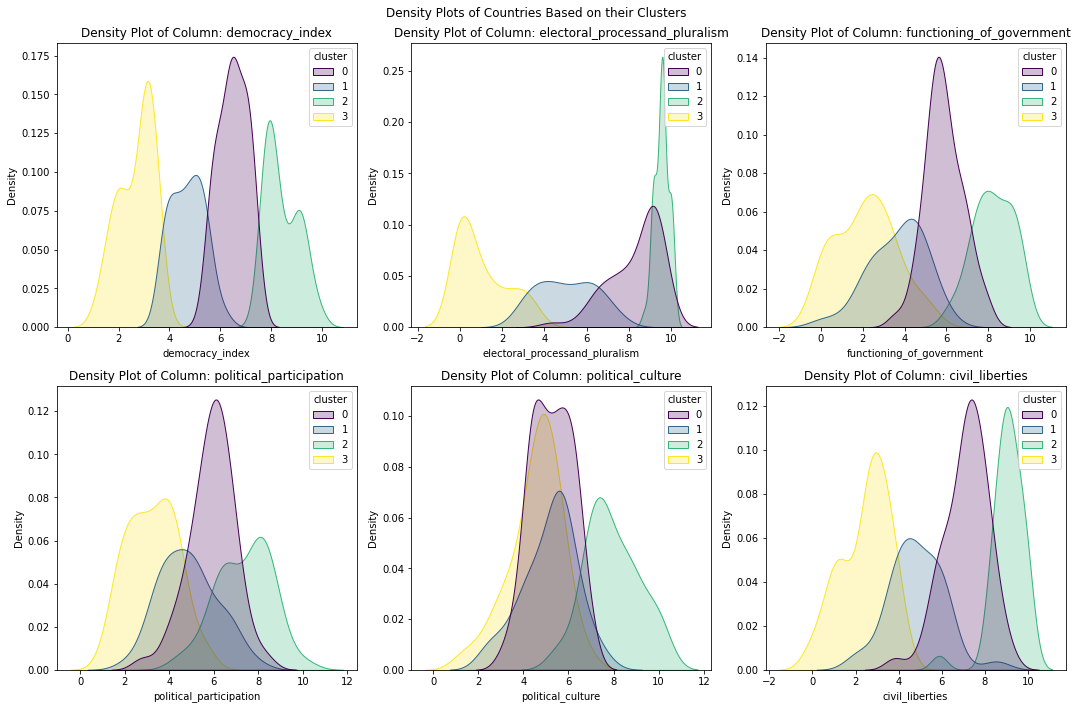

In [ ]:
features=dataset.columns.drop(['Unnamed: 0','rank', 'country','category','cluster'])
#gather all the features that need to be graphed. Categorical features do not need to be included

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes= axes.flatten()
#allows iterating through subplots without having to calculate which subplot is needed

for i, column in enumerate(features):
    #column represents each feature and i represents the index value of the current feature
    sns.kdeplot(data=dataset, x=column, hue='cluster', fill=True, palette='viridis', ax=axes[i])
    #a kdeplot, or density plot, is created. x represents the feature currently being plotted at subplot i
    #hue plots each cluster separately on the same subplot, and ax accesses the subplot for the feature being plotted 
    axes[i].set_title(f'Density Plot of Column: {column}')
    #sets a title for each subplot
    
#set a centered suptitle for the graph and makes sure the layouts do not overlap
plt.suptitle("Density Plots of Countries Based on their Clusters")
plt.tight_layout()
plt.show()

The graph above depicts the countries as density clusters for each feature of the dataset. Many observations could be made, such as cluster 0 having a much denser political participation score and functioning of government score than the other three clusters. Clusters 0 and 2 also have similar densities relating to their civil liberty scores. Many other observations could be made.

The most challenging part of this project for me was to figure out how to iteratively plot the density plots on subplots for easier comparison. I found that through the axes.flatten() method, I can iterate over a 1D array instead of a 2D array of axes objects, which calls for much faster iteration and access of subplots.

- All codes should be well-commented to explain your thought process and implementation details. 
- Include all visualizations in your final report. 
- Your report should detail the steps you took, any challenges faced, and the insights or conclusions you drew from the visualizations  

### Evaluation Criteria:
 
**Tasks to be Completed and their point values:**
- Variable selection and scaling (10 points)
- K-means clustering implementation (40 points)
- Hierarchical clustering implementation (40 points)
- Density Plots (10 points)